In [ ]:
                        #-----Categorical Missing Value--------#
# When a categorical feature (like Sex, Embarked, City, Tumor Type, etc.) has missing entries.

# Method to handale Categorical Missing Value:

# Most Frequent Imputation: Replace missing with the most common category.
    #  
# When to use:
    # Missing is Small (<5%)
    # Data is missing completely at Random (MCAR)

# Add new category named missing: Very powerfull and commonly used
    # Preserves information
    # Model can learn missing pattern
    # Works very well with tree models


In [10]:
# #xample code of Most frequent missing Imputation
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

In [2]:
# Import required Dataset
Df=pd.read_csv('train.csv', usecols=['GarageQual', 'FireplaceQu', 'SalePrice'])

In [3]:
# Check missing
Df.isnull().mean()*100

FireplaceQu    47.260274
GarageQual      5.547945
SalePrice       0.000000
dtype: float64

Text(0, 0.5, 'Number of houses')

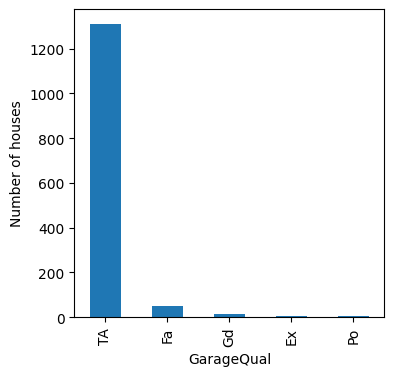

In [4]:
# Work with GarageQual
plt.figure(figsize=(4,4))
Df['GarageQual'].value_counts().sort_values(ascending=False).plot.bar()
plt.xlabel('GarageQual')
plt.ylabel('Number of houses')

In [5]:
# Identify most frequent number
Df['GarageQual'].mode()

0    TA
Name: GarageQual, dtype: object

Text(0.5, 1.0, 'GarageQual')

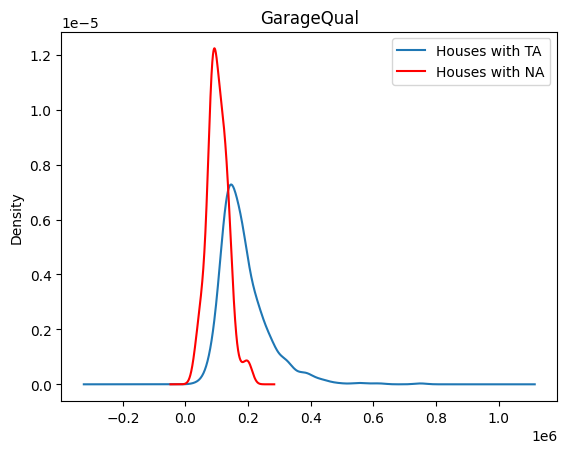

In [6]:
# Compare distribution of TA and NA
fig = plt.figure()
ax = fig.add_subplot(111)

Df[Df['GarageQual']=='TA']['SalePrice'].plot(kind='kde', ax=ax)

Df[Df['GarageQual'].isnull()]['SalePrice'].plot(kind='kde', ax=ax, color='red')

lines, labels = ax.get_legend_handles_labels()
labels = ['Houses with TA', 'Houses with NA']
ax.legend(lines, labels, loc='best')

plt.title('GarageQual')

In [7]:
temp=Df[Df['GarageQual']=='TA']['SalePrice']
Df['GarageQual'].fillna('TA', inplace=True)

C:\Users\Kamely\AppData\Local\Temp\ipykernel_6736\68184601.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  Df['GarageQual'].fillna('TA', inplace=True)


<Axes: xlabel='GarageQual'>

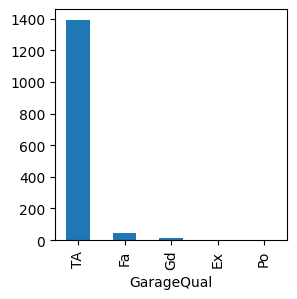

In [8]:
# Darw plot
plt.figure(figsize=(3,3))
Df['GarageQual'].value_counts().plot(kind='bar')

Text(0.5, 1.0, 'GarageQual')

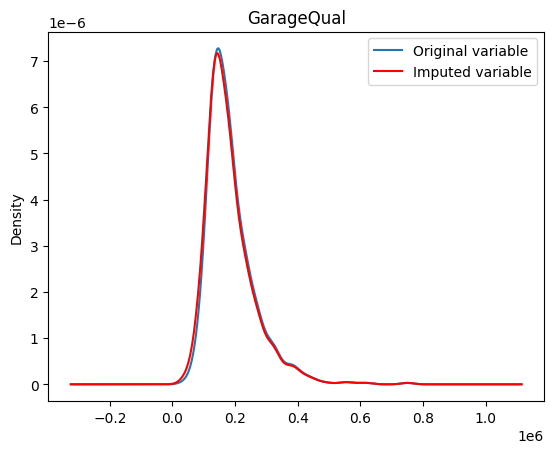

In [9]:
# Now draw plot
fig = plt.figure()
ax = fig.add_subplot(111)


temp.plot(kind='kde', ax=ax)

# distribution of the variable after imputation
Df[Df['GarageQual'] == 'TA']['SalePrice'].plot(kind='kde', ax=ax, color='red')

lines, labels = ax.get_legend_handles_labels()
labels = ['Original variable', 'Imputed variable']
ax.legend(lines, labels, loc='best')

# add title
plt.title('GarageQual')

In [13]:
# Impute using Sklearn
X_train, X_test, y_train, y_test=train_test_split(
    Df.drop(columns=['SalePrice']),
    Df['SalePrice'],
    test_size=0.2
)

In [14]:
# Import simpleimputer
from sklearn.impute import SimpleImputer

In [15]:
# Create Object
imputer=SimpleImputer(strategy='most_frequent')

In [16]:
# Transform X_train and X_test
X_train=imputer.fit_transform(X_train)
X_test=imputer.transform(X_test)

In [17]:
# Check Statistics
imputer.statistics_

array(['Gd', 'TA'], dtype=object)

In [19]:
# Missing Category Imputation
X_train, X_test, y_train, y_test=train_test_split(
    Df.drop(columns=['SalePrice']),
    Df['SalePrice'],
    test_size=0.2
)

In [20]:
from sklearn.impute import SimpleImputer

In [23]:
# Create Object
imputer1=SimpleImputer(strategy='constant', fill_value='Missing')

In [24]:
# Transform X_train and X_test
X_train=imputer1.fit_transform(X_train)
X_test=imputer1.transform(X_test)

In [25]:
imputer1.statistics_

array(['Missing', 'Missing'], dtype=object)